In [13]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict


In [14]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
import os
load_dotenv()
api_key=os.getenv("OPENROUTER_API_KEY")
llm=ChatOpenAI(api_key=api_key,base_url="https://openrouter.ai/api/v1",model='openai/gpt-4o-mini')



In [15]:
result=llm.invoke("what is the capital of newyork")
print(result.content)

The capital of New York is Albany.


In [16]:
class BlogState(TypedDict):
    title: str
    outline: str
    content: str

In [17]:
graph=StateGraph(BlogState)

In [18]:
def create_outline(state:BlogState)->BlogState:
    #extact the title
    title=state['title']
    #promt
    prompt=f'generate a detailed outline for a blog on the topic - {title}'
    #call llm
    outline=llm.invoke(prompt).content
    #state update
    state['outline']=outline
    return state


In [19]:
def create_blog(state:BlogState)->BlogState:
    title=state['title']
    outline=state['outline']
    prompt=f'write a detailed blog on the title - {title} using the following outline\n{outline}'
    content=llm.invoke(prompt).content
    state['content']=content
    return state

In [20]:
#nodes
graph.add_node('create_outline',create_outline)
graph.add_node('create_blog',create_blog)
#add edges
graph.add_edge(START,'create_outline')
graph.add_edge('create_outline','create_blog')
graph.add_edge('create_blog',END)
#compile
workflow=graph.compile()

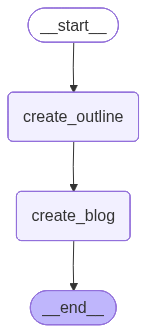

In [21]:
workflow

In [23]:
initial_state={'title':'my country india'}
final_state=workflow.invoke(initial_state)

In [27]:
print(final_state['content'])

# My Country India

## I. Introduction
“India is not a nation, nor a country. It is a subcontinent of nationalities.” – Walter Lawrence

This profound statement encapsulates the essence of India, a land where diversity thrives in every form. It’s a tapestry woven from the threads of different cultures, languages, traditions, and landscapes. In this blog post, I aim to take you on a journey through my beloved homeland, sharing personal experiences and insights that highlight the richness of India.

From its breathtaking geographical features and cultural nuances to its historical significance and modern challenges, India is a country like no other. Join me as we explore the many dimensions that make India a unique and mesmerizing place.

## II. Geography and Natural Diversity
India’s geographical features are as diverse as its people. 

### A. Overview of India’s Geographical Features
1. **Mountains**: The majestic Himalayas crown the northern border, standing tall as a testament to nat

In [26]:
print(final_state['outline'])

Sure! Here’s a detailed outline for a blog post titled "My Country India."

### Outline: My Country India

#### I. Introduction
   A. Hook: A captivating opening statement or quote about India
   B. Purpose of the blog: Share personal experiences and insights about India
   C. Brief overview of what the post will cover

#### II. Geography and Natural Diversity
   A. Overview of India’s geographical features
      1. Mountains (Himalayas)
      2. Rivers (Ganges, Yamuna, Brahmaputra)
      3. Deserts (Thar Desert)
      4. Coastal regions
   B. Climate and Seasons
      1. Monsoon season
      2. Variability across regions
   C. Biodiversity
      1. Flora and fauna
      2. National parks and wildlife sanctuaries

#### III. Cultural Diversity
   A. Languages
      1. Overview of major languages spoken
      2. Importance of regional dialects
   B. Religions
      1. Major religions (Hinduism, Islam, Christianity, Sikhism, Buddhism, etc.)
      2. Festivals and their significance
   C. 